# В чем заключалось задание

### Существует движение материальной точки (космического корабля) со своей массой m в гравитационном поле неподвижного силового центра (звезды) массой M. Однако, масса звезды значительно превышает массу корабля (M≫m), что позволяет пренебречь движением самой звезды и считать её положение началом инерциальной системы координат.

In [224]:
import numpy as np
import matplotlib.pyplot as plt

##### В функции sole_central_field используются константы из выведенных доказательств и констант, которые даны из условия задания

In [225]:
def solve_central_field():
    # ==== Константы ====
    G = 6.67430e-11 # Гравитационная постоянная
    M = 2e30 # Масса звезды
    R = 7e8 # Радиус звезды 
    mu = G * M

    print("Движение в центральном поле сил")
    print("--------------------------------")
    
    level = int(input("Введите уровень задания (1 или 2): "))

    if level == 1:
        x0 = float(input("x0 (м) = "))
        y0 = float(input("y0 (м) = "))
        vx0 = float(input("vx0 (м/с) = "))
        vy0 = float(input("vy0 (м/с) = "))
        solve_level_1(x0, y0, vx0, vy0, mu, R)
    elif level == 2:
        r0 = float(input("r0 (м) = "))
        v0 = float(input("v0 (м/с) = "))
        solve_level_2(r0, v0, mu, R)
    else:
        print("Ошибка: введите 1 или 2.")


### Проверка пересечения траектории с поверхностью звезды

##### Так как из условия задания нельзя использовать дифференциальные уравнеия, то воспользуемся уравнениями в полярных координатах для проверки пересечения траектории со свездой, а также как двигается корабль вокруг звезды

##### Сама формула выглядит так: 

$$cos(\theta - \omega) =  \frac{\frac{p}{R}-1}{e}$$

##### Преобразуем 
$$r(\theta) = \frac{p}{1 + e \cdot \cos(\theta - \omega)}$$

##### Кроме этого, находим углы - т.е. две точки alpha и -alpha (при помощи функции arccos), которые симметричные орбиты - записанные candidates.



In [226]:
def first_future_collision(theta0, omega, e, p, R, dir_sign):
    if e < 1e-12:
        return False, None
    
    c = (p / R - 1) / e
    
    if abs(c) > 1:
        return False, None
    
    alpha = np.arccos(np.clip(c, -1, 1))
    candidates = omega + np.array([alpha, -alpha])
    
    best_delta = np.inf
    theta_hit = None
    
    # Проверка на несколько оборотов вперед
    for base_th in candidates:
        for shift in 2 * np.pi * np.arange(-1, 2):
            th = base_th + shift
            if dir_sign > 0:
                d = (th - theta0) % (2 * np.pi)
            else:
                d = (theta0 - th) % (2 * np.pi)
            
            if 1e-10 < d < best_delta:
                best_delta = d
                theta_hit = th if dir_sign > 0 else theta0 - d
                
    if np.isfinite(best_delta):
        return True, theta_hit
    return False, None

### Расчет параметтров орбиты для общего случая (произвольные координаты и скорость) - 1 уровня

##### В программе использовали вектор эксцентриситета (е) - в программе e_vec, который всегда направлен из центра в сторону перицентра. Длина сам эксцентриситет e, а угол (через функцию arctan2) - ориентация орбиты в пространтве.

$$e = \frac{(v^2 - \frac{μ}{r})r - (r*v)v}{μ} $$

##### Далее воспользовались переходом от полярных координат к декартовым для отрисовки передвижения материальной точки, вот формулы:

$$ x = r*cos(\theta)$$
$$y = r*sin(\theta)$$

In [227]:
def solve_level_1(x0, y0, vx0, vy0, mu, R):
    rvec = np.array([x0, y0])
    vvec = np.array([vx0, vy0])
    r0 = np.linalg.norm(rvec)
    v0 = np.linalg.norm(vvec)
    
    # Расчет параметров
    h = x0 * vy0 - y0 * vx0
    eps = 0.5 * v0**2 - mu / r0
    vc = np.sqrt(mu / r0)
    e_vec = ((v0**2 - mu/r0) * rvec - np.dot(rvec, vvec) * vvec) / mu
    e = np.linalg.norm(e_vec)
    p = h**2 / mu
    omega = np.arctan2(e_vec[1], e_vec[0])
    theta0 = np.arctan2(y0, x0)
    rp = p / (1 + e) # Перицентр (мин. расстояние)
    
    orbit_type = "эллипс" if eps < -1e-12 else ("парабола" if abs(eps) < 1e-12 else "гипербола")
    hit, theta_hit = first_future_collision(theta0, omega, e, p, R, np.sign(h))

    # Вывод информации
    print(f"\n----- Уровень 1 -----")
    print(f"r0   = {r0:.6e} м")
    print(f"v0   = {v0:.6e} м/с")
    print(f"v_кр = {vc:.6e} м/с")
    print(f"eps  = {eps:.6e} Дж/кг")
    print(f"e    = {e:.6e}")
    print(f"p    = {p:.6e} м")
    hit_str = "Столкновение будет." if hit else "Столкновения не будет."
    print(f"Тип: {orbit_type}. Минимальный радиус rp = {rp:.6e} м. {hit_str}")

    if r0 <= R:
        plot_orbit(None, None, R, x0, y0, "Столкновение (старт внутри звезды)")
        return

    # Подготовка траектории
    if hit:
        theta = np.linspace(theta0, theta_hit, 1000)
    else:
        theta = np.linspace(0, 2*np.pi, 1000) if e < 1 else np.linspace(omega - np.arccos(-1/e)+0.1, omega + np.arccos(-1/e)-0.1, 1000)
            
    r = p / (1 + e * np.cos(theta - omega))
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    plot_orbit(x, y, R, x0, y0, f"Уровень 1: {orbit_type}")

### Расчет для частного случая, когда скорость строго перпендикулярна радиусу - 2 уровня

##### Здесь рассматривались ситуации, что  начальная точка $r_0$ обязана быть либо перицентром, либо апоцентом.

##### Важным параметром являлось круговая скорость $v_c = \sqrt{\frac{μ}{r_0}}$

##### Случаи:
##### 1) Если $v_0 = v_c, то $ $ \epsilon = \frac{-μ}{2*r_0}, $ $ e - это окружность

##### 2) Если $v_0 > v_c, то $ $ {r_0} - это перицентр, корабль начинает удаляться

##### 3) Если $v_0 < v_c, то $ $ {r_0} - это апоцентр, корабль начинает падать к звезде

In [228]:
def solve_level_2(r0, v0, mu, R):
    # Параметры для касательного старта
    vc = np.sqrt(mu / r0)
    eps = 0.5 * v0**2 - mu / r0
    e = abs(r0 * v0**2 / mu - 1)
    p = (r0 * v0)**2 / mu
    rp = p / (1 + e)
    
    orbit_type = "окружность" if abs(v0 - vc) < 1e-12 else ("эллипс" if eps < 0 else "гипербола")
    
    # Старт на оси X
    theta0 = 0
    omega = 0 if v0 >= vc else np.pi
    hit, theta_hit = first_future_collision(theta0, omega, e, p, R, 1)

    # Вывод информации
    print(f"\n----- Уровень 2 -----")
    print(f"r0   = {r0:.6e} м")
    print(f"v0   = {v0:.6e} м/с")
    print(f"v_кр = {vc:.6e} м/с")
    print(f"eps  = {eps:.6e} Дж/кг")
    print(f"e    = {e:.6e}")
    print(f"p    = {p:.6e} м")
    hit_str = "Столкновение будет." if hit else "Столкновения не будет."
    print(f"Тип: {orbit_type}. Минимальный радиус rp = {rp:.6e} м. {hit_str}")

    if r0 <= R: return

    # Подготовка траектории
    if hit:
        theta = np.linspace(theta0, theta_hit, 1000)
    else:
        theta = np.linspace(0, 2*np.pi, 1000) if e < 1 else np.linspace(-np.arccos(-1/e)+0.1, np.arccos(-1/e)-0.1, 1000)
        
    r = p / (1 + e * np.cos(theta - omega))
    plot_orbit(r * np.cos(theta), r * np.sin(theta), R, r0, 0, f"Уровень 2: {orbit_type}")

Движение в центральном поле сил
--------------------------------

----- Уровень 1 -----
r0   = 1.000000e+10 м
v0   = 1.630000e+05 м/с
v_кр = 1.155361e+05 м/с
eps  = -6.410000e+07 Дж/кг
e    = 9.903960e-01
p    = 1.990396e+10 м
Тип: эллипс. Минимальный радиус rp = 1.000000e+10 м. Столкновения не будет.


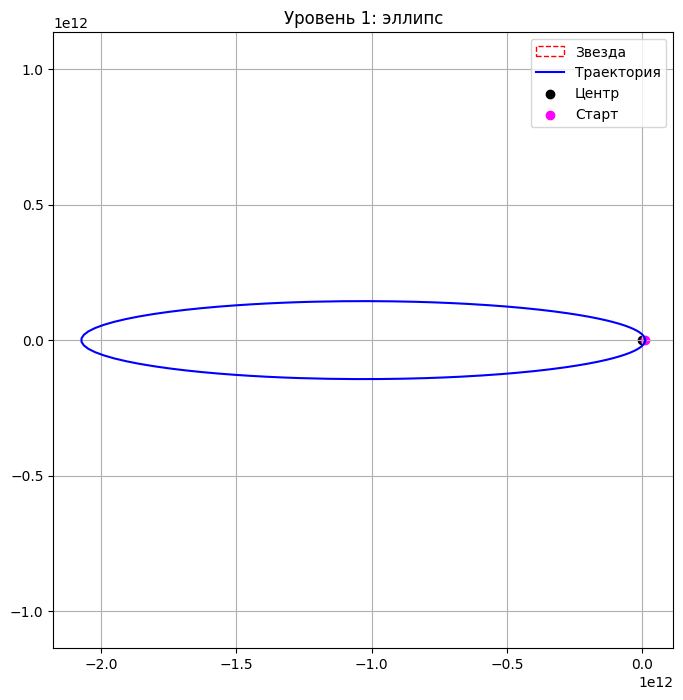

In [229]:
def plot_orbit(x, y, R, x0, y0, title_str):
    plt.figure(figsize=(8, 8))
    circle = plt.Circle((0, 0), R, color='red', fill=False, linestyle='--', label='Звезда')
    plt.gca().add_patch(circle)
    if x is not None:
        plt.plot(x, y, 'b', label='Траектория')
    plt.scatter([0], [0], color='black', label='Центр')
    plt.scatter([x0], [y0], color='magenta', label='Старт')
    plt.axis('equal')
    plt.grid(True)
    plt.title(title_str)
    plt.legend()
    plt.show()

# Запуск
solve_central_field()

### Набор тестовых значений для обоих уровней:

#### Уровень 1

1)  x0 = 1e10; y0 = 0; vx0 = 0; vy0 = 1.63e5; - получается эллипс, в котором столкновения не будет
----- Уровень 1 -----
r0   = 1.000000e+10 м
v0   = 1.630000e+05 м/с
v_кр = 1.155361e+05 м/с
eps  = -6.410000e+07 Дж/кг
e    = 9.903960e-01
p    = 1.990396e+10 м
Тип: эллипс. Минимальный радиус rp = 1.000000e+10 м. Столкновения не будет.

2) x0 = 1e10; y0 = 0; vx0 = 0; vy0 = 2.5e5; - получается гипербола, в котором столкновения не будет
Вывод:
----- Уровень 1 -----
r0   = 1.000000e+10 м
v0   = 2.500000e+05 м/с
v_кр = 1.155361e+05 м/с
eps  = 1.790140e+10 Дж/кг
e    = 3.682139e+00
p    = 4.682139e+10 м

3) x0 = 1e8; y0 = 0; vx0 = 1e2; vy0 = 0; - заметим что столкновения нет, но корабль уже внутри звезды

4) x0 = 1e10; y0 = 1e10; vx0 = -5e4; vy0 = 7e4; - движение вокруг звезды
----- Уровень 1 -----
r0   = 1.414214e+10 м
v0   = 8.602325e+04 м/с
v_кр = 9.715393e+04 м/с
eps  = -5.738886e+09 Дж/кг
e    = 2.691206e-01
p    = 1.078765e+10 м
Тип: эллипс. Минимальный радиус rp = 8.500097e+09 м. Столкновения не будет.

5) x0 = 8e9; y0 = 3e9; vx0 = -4e4; vy0 = 6e4; - движение вокруг звезды
----- Уровень 1 -----
r0   = 8.544004e+09 м
v0   = 7.211103e+04 м/с
v_кр = 1.249934e+05 м/с
eps  = -1.302335e+10 Дж/кг
e    = 6.883022e-01
p    = 2.696912e+09 м
Тип: эллипс. Минимальный радиус rp = 1.597411e+09 м. Столкновения не будет.



### Набор тестовых значений для обоих уровней:

#### Уровень 2

1) r0 = 1e10; v0 = 1.155e5; движение вокруг звезды

----- Уровень 2 -----
r0   = 1.000000e+10 м
v0   = 1.155000e+05 м/с
v_кр = 1.155361e+05 м/с
eps  = -6.678475e+09 Дж/кг
e    = 6.255338e-04
p    = 9.993745e+09 м
Тип: эллипс. Минимальный радиус rp = 9.987497e+09 м. Столкновения не будет.

2) r0 = 1e10; v0 = 2.5e4; - видим, что траектория материальной точки движется к поверхности звезды
----- Уровень 2 -----
r0   = 1.000000e+10 м
v0   = 2.500000e+04 м/с
v_кр = 1.155361e+05 м/с
eps  = -1.303610e+10 Дж/кг
e    = 9.531786e-01
p    = 4.682139e+08 м
Тип: эллипс. Минимальный радиус rp = 2.397189e+08 м. Столкновение будет.


3) r0 = 8e8; v0 = 1.2e5; - столкновение со звездой
----- Уровень 2 -----
r0   = 8.000000e+08 м
v0   = 1.200000e+05 м/с
v_кр = 4.084819e+05 м/с
eps  = -1.596575e+11 Дж/кг
e    = 9.136988e-01
p    = 6.904095e+07 м
Тип: эллипс. Минимальный радиус rp = 3.607723e+07 м. Столкновение будет.

4) r0 = 2e10; v0 = 5e4; - движение по эллипсу
----- Уровень 2 -----
r0   = 2.000000e+10 м
v0   = 5.000000e+04 м/с
v_кр = 8.169639e+04 м/с
eps  = -5.424300e+09 Дж/кг
e    = 6.254289e-01
p    = 7.491422e+09 м
Тип: эллипс. Минимальный радиус rp = 4.608890e+09 м. Столкновения не будет.

5) r0 = 1e10; v0 = 1; - видим, что движение материальной точки - прямая 
----- Уровень 2 -----
r0   = 1.000000e+10 м
v0   = 1.000000e+00 м/с
v_кр = 1.155361e+05 м/с
eps  = -1.334860e+10 Дж/кг
e    = 1.000000e+00
p    = 7.491422e-01 м
Тип: эллипс. Минимальный радиус rp = 3.745711e-01 м. Столкновение будет.